# 案例 06 · 碳排放：C919（代理机型）与 A320neo 每座公里的碳强度

**这个案例回答什么？**
- 同一条航线，两款窄体机的**轮档 CO₂** 差多少？
- 摊到**每座每公里**之后还剩多少差距？（这才是航司与监管真正看的口径）
- 碳价（CORSIA / EU ETS 情景）会让航线成本多出几个百分点？

**方法**：CO₂ 主数字 = 轮档燃油 × **3.16 kg CO₂/kg 煤油**（ICAO/IPCC 因子，
本质是化学计量——这是碳数字里最坚实的部分，不确定性全在油量模型一侧）。
分项排放（NOx/H₂O 随燃烧状态变化）用 OpenAP `Emission` 模型演示。

**诚实话**：简化常数油耗模型 + 3.16 因子 → CO₂ 结论的精度与油量精度一致；
CORSIA/ETS 规则（豁免、抵销、价格）在此只作情景参数，不代表任何合规计算。

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from routelab.adaptability import adapt_for_airport  # noqa: F401  (sentinel for v2 modules)
from routelab.airports import AirportDB
from routelab.fuel import FuelPolicy
from routelab.planning import plan_leg
from routelab.presets import PRESET_AIRCRAFT

db = AirportDB()
policy = FuelPolicy()
FLEET = [PRESET_AIRCRAFT["A320neo (公开手册量级)"],
         PRESET_AIRCRAFT["737 MAX 8 (公开手册量级)"],
         PRESET_AIRCRAFT["C919 (公开报道+估计，非官方)"]]
ROUTES = [("ZSPD", "ZBAA"), ("ZSPD", "ZGGG"), ("ZSPD", "ZWWW"),
          ("ZBAA", "ZPPP"), ("ZUUU", "ZWWW")]

## 1. 五条国内干线 × 三款机型：每座每公里 CO₂

In [2]:
rows = []
for o, d in ROUTES:
    for ac in FLEET:
        plan = plan_leg(db, ac, o, d, "", payload_kg=0.8 * ac.max_payload_kg,
                        seats=ac.seats, policy=policy)
        rows.append({
            "航线": f"{o}-{d}",
            "机型": ac.name,
            "航距 km": round(plan.route.distance_km),
            "轮档油 t": round(plan.fuel.block_kg / 1000, 2),
            "CO2 t": round(plan.co2_kg / 1000, 2),
            "座公里 CO2 g": round(plan.co2_per_seat_km * 1000, 1),
        })
emis = pd.DataFrame(rows)
emis

,航线,机型,航距 km,轮档油 t,CO2 t,座公里 CO2 g
0,ZSPD-ZBAA,A320neo,1099,5.58,17.63,92.2
1,ZSPD-ZBAA,737 MAX 8,1099,5.82,18.38,94.0
2,ZSPD-ZBAA,C919 (estimates),1099,6.00,18.95,105.2
3,ZSPD-ZGGG,A320neo,1203,5.83,18.44,88.1
4,ZSPD-ZGGG,737 MAX 8,1203,6.09,19.23,89.8
5,ZSPD-ZGGG,C919 (estimates),1203,6.28,19.83,100.5
6,ZSPD-ZWWW,A320neo,3312,11.02,34.82,60.4
7,ZSPD-ZWWW,737 MAX 8,3312,11.50,36.33,61.6
8,ZSPD-ZWWW,C919 (estimates),3312,11.89,37.58,69.2
9,ZBAA-ZPPP,A320neo,2094,8.02,25.35,69.6


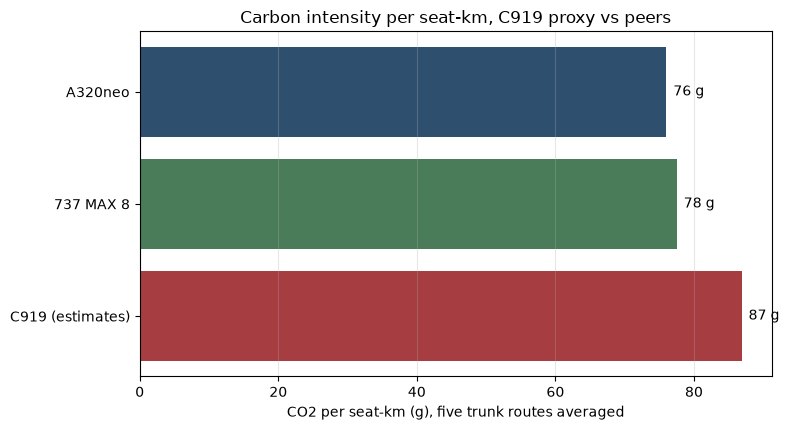

机型
A320neo             76.0
737 MAX 8           77.5
C919 (estimates)    86.9
Name: 平均座公里 CO2 g, dtype: float64

In [3]:
avg = emis.groupby("机型", sort=False)["座公里 CO2 g"].mean().rename("平均座公里 CO2 g")
fig, ax = plt.subplots(figsize=(8, 4.4))
bars = ax.barh(avg.index[::-1], avg[::-1],
               color=["#a63d40", "#4a7c59", "#2f4f6f"])
for b, v in zip(bars, avg[::-1]):
    ax.text(v + 1, b.get_y() + b.get_height() / 2, f"{v:.0f} g", va="center", fontsize=10)
ax.set_xlabel("CO2 per seat-km (g), five trunk routes averaged")
ax.set_title("Carbon intensity per seat-km, C919 proxy vs peers")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()
avg.round(1)

**读数**：三款同级窄体机的**每座公里碳强度在同一量级**（±10% 内）——
这本身就是 C919 市场故事的核心论据：新一代窄体机的碳效率彼此接近，
差异主要来自座位数与每座重量，而不是引擎代差。

## 2. 碳成本情景：碳价如何改写航线油钱

In [4]:
ROUTE_OIL = emis[emis["航线"] == "ZSPD-ZWWW"].copy()
CARBON_PRICES = [0, 500, 1500, 3000]   # CNY / t CO2 情景（示例，非预测）

rows = []
for _, r in ROUTE_OIL.iterrows():
    row = {"机型": r["机型"], "CO2 t": r["CO2 t"]}
    for price in CARBON_PRICES:
        row[f"碳成本 @{price}元/t"] = round(r["CO2 t"] * price / 1000, 2)  # 千元
    rows.append(row)
cost = pd.DataFrame(rows)
cost["备注"] = "轮档 CO2，往返未计"
cost

,机型,CO2 t,碳成本 @0元/t,碳成本 @500元/t,碳成本 @1500元/t,碳成本 @3000元/t,备注
0,A320neo,34.82,0.0,17.41,52.23,104.46,轮档 CO2，往返未计
1,737 MAX 8,36.33,0.0,18.16,54.49,108.99,轮档 CO2，往返未计
2,C919 (estimates),37.58,0.0,18.79,56.37,112.74,轮档 CO2，往返未计


**读数**：在 1,500 元/吨 CO₂ 的强情景下，一条浦东—虹桥级干线单程碳成本
约 3–5 万元量级——与航段燃油成本的百分比随油价浮动（本案例不展开），
但趋势明确：**碳效率每差 5%，未来的碳账单就差 5%**。CORSIA 与 ETS 的
真实规则（豁免额、免费配额、抵销）远比这里的线性计价复杂。

## 3. 分项排放演示：为什么 NOx 不能用燃油乘数

In [5]:
try:
    from routelab.emissions import openap_emission_rates
    rates = openap_emission_rates("a320", mass_kg=70_000)
    pd.Series(rates).rename("kg/s @70t FL350 M0.78").round(5).to_frame()
except ImportError as exc:
    print(f"[跳过] {exc}")
    pd.DataFrame()

**读数**：CO₂ 与 H₂O 几乎严格正比于燃油（完全燃烧的化学计量），
**NOx 不然**——它取决于燃烧室温度与停留时间，同样油量下不同高度/速度的
NOx 可以差出几十个百分点。这就是监管把 NOx 单列适航条款、而 CO₂ 走
燃油口径的原因。

## 结论与局限

- 同级窄体机每座公里 CO₂ 处于同一量级（约 90–110 g），机型之争的碳差距
  远小于客座率之争——**装满每一个座位比换一架飞机更减碳**；
- 碳价线性情景显示碳成本正在成为航线经济性的常驻项；
- **局限**：常数油耗 + 3.16 因子的组合继承了油量模型的全部粗粝；
  NOx/H₂O 演示为单点瞬时值未积分；碳价情景不是预测。